# Lifestyle Archetypes and Problematic Internet Use

**Question:** Given patterns of sleep, physical activity and body composition, do distinct lifestyle profiles emerge among children and adolescents, and how do these profiles relate to problematic internet use (PIU) and mental health screening scores?

**Important analytical boundary (Responsible Analysis Requirement, Section 8):**
- This is an **unsupervised, exploratory segmentation** task, not a predictive or diagnostic modelling task.
- PIU and mental health scores here are **screening instrument results, not clinical diagnoses**.
- Clusters describe **population-level lifestyle patterns**. They must never be used to label, diagnose, or make judgements about any individual child.
- Any outcome association reported below (Section 10) is **preliminary and subset-derived** (train-set labels only) and is reported as an association, not a validated clinical finding.

## Notebook structure
1. Data dictionary review
2. Missingness documentation
3. Actigraphy (accelerometer) feature extraction
4. Feature engineering & merge
5. Exploratory data analysis
6. Dimensionality reduction (UMAP)
7. Clustering comparison (K-means, Agglomerative, DBSCAN)
8. Cluster validation (silhouette, Davies-Bouldin, Calinski-Harabasz)
9. Stability analysis (subsampling + noise sensitivity)
10. Archetype characterisation & relation to PIU / mental health
11. Visual summary (UMAP plot, radar charts, heatmap)
12. Optional stretch: robustness of cluster-PIU association
13. Written summary & limitations


In [1]:
import os

os.listdir("/kaggle/input")

['competitions']

In [2]:
import os

os.listdir("/kaggle/input/competitions")

['child-mind-institute-problematic-internet-use']

In [4]:
from pathlib import Path

DATA_DIR = Path("/kaggle/input/competitions/child-mind-institute-problematic-internet-use")

In [5]:
import os

os.listdir(DATA_DIR)

['sample_submission.csv',
 'data_dictionary.csv',
 'series_test.parquet',
 'series_train.parquet',
 'train.csv',
 'test.csv']

In [6]:
TRAIN_CSV = DATA_DIR / "train.csv"
TEST_CSV = DATA_DIR / "test.csv"
SAMPLE_SUBMISSION = DATA_DIR / "sample_submission.csv"
DATA_DICTIONARY = DATA_DIR / "data_dictionary.csv"

SERIES_TRAIN_DIR = DATA_DIR / "series_train.parquet"
SERIES_TEST_DIR = DATA_DIR / "series_test.parquet"

In [8]:
!pip -q install umap-learn pyarrow scikit-learn-extra missingno

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 11.0 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [11]:
import os
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import f_oneway, chi2_contingency, kruskal

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import umap.umap_ as umap

import pyarrow.parquet as pq

In [14]:
DATA_DIR = Path(
    "/kaggle/input/competitions/child-mind-institute-problematic-internet-use"
)

TRAIN_CSV = DATA_DIR / "train.csv"
TEST_CSV = DATA_DIR / "test.csv"
DATA_DICTIONARY = DATA_DIR / "data_dictionary.csv"
SAMPLE_SUBMISSION = DATA_DIR / "sample_submission.csv"

SERIES_DIR = DATA_DIR / "series_train.parquet"
SERIES_TEST_DIR = DATA_DIR / "series_test.parquet"

CACHE_PATH = Path("/kaggle/working/actigraphy_summary.csv")

In [15]:
train = pd.read_csv(TRAIN_CSV)
test = pd.read_csv(TEST_CSV)
dictionary = pd.read_csv(DATA_DICTIONARY)

## 1. Understanding the Dataset (Data Dictionary Review)

Before creating any new features or running any analysis, it is important to understand what each group of variables represents. The **Child Mind Institute (CMI) Healthy Brain Network** dataset organises variables into different sections based on the questionnaire, assessment, or measurement from which they were collected.

The main groups of variables are:

| Variable Group | Full Name | What It Contains |
|----------------|-----------|------------------|
| **Basic_Demos** | Basic Demographics | Participant information such as age, sex, and basic background characteristics. |
| **CGAS** | Children's Global Assessment Scale | A clinician-rated measure of a child's overall psychological, social, and school functioning. Higher scores generally indicate better functioning. |
| **Physical** | Physical Measurements | Height, weight, Body Mass Index (BMI), waist circumference, blood pressure, heart rate, and other physical health measurements. |
| **FGC** | FitnessGram Components | Measures of physical fitness such as grip strength, flexibility, muscular endurance, and cardiovascular fitness. |
| **BIA** | Bioelectrical Impedance Analysis | Body composition measurements including body fat percentage, lean muscle mass, total body water, and related metrics. |
| **PAQ_A** | Physical Activity Questionnaire for Adolescents | A self-reported questionnaire measuring the physical activity levels of adolescents (typically ages 14–20) over the previous seven days. |
| **PAQ_C** | Physical Activity Questionnaire for Children | A child-friendly version of the physical activity questionnaire designed for younger participants (typically ages 8–14). |
| **PCIAT** | Parent–Child Internet Addiction Test | A questionnaire assessing problematic internet use (PIU). It measures behaviours such as excessive internet use, difficulty controlling internet use, and its impact on daily life. This is the primary outcome used later to compare lifestyle archetypes—it is **not** used to create the clusters themselves. |
| **SDS** | Sleep Disturbance Scale for Children | A questionnaire measuring different aspects of children's sleep, including sleep quality, sleep disorders, and disturbances. |
| **PreInt_EduHx** | Prenatal, Intervention and Educational History | Information about prenatal history, developmental milestones, educational support, previous interventions, and learning history. |

### Accelerometer (Wearable) Data

In addition to the questionnaire and clinical measurements, the dataset includes wearable accelerometer data stored separately as:

- `series_train.parquet`
- `series_test.parquet`

These files contain continuous movement data collected from wearable devices (actigraphy). Unlike the questionnaire data, they record participants' activity throughout the day and night.

From these time-series data, we can engineer lifestyle features such as:

- Average nightly sleep duration
- Night-to-night sleep variability
- Physical activity intensity
- Daily activity consistency
- Circadian (day–night) activity patterns

These engineered features provide objective measurements of participants' lifestyles and form the basis of the clustering analysis used to identify different lifestyle archetypes.

In [16]:
print("train shape:", train.shape)
print("test shape :", test.shape)
print("dictionary shape:", dictionary.shape)

display(dictionary.head(20))

# Column families present in train, grouped by instrument prefix
families = sorted(set(c.split("-")[0] for c in train.columns if "-" in c))
print("\nInstrument families in train.csv:")
for fam in families:
    cols = [c for c in train.columns if c.startswith(fam + "-")]
    print(f"  {fam:15s} -> {len(cols)} columns")


train shape: (3960, 82)
test shape : (20, 59)
dictionary shape: (81, 6)


,Instrument,Field,Description,Type,Values,Value Labels
0,Identifier,id,Participant's ID,str,NaN,NaN
1,Demographics,Basic_Demos-Enroll_Season,Season of enrollment,str,"Spring, Summer, Fall, Winter",NaN
2,Demographics,Basic_Demos-Age,Age of participant,float,NaN,NaN
3,Demographics,Basic_Demos-Sex,Sex of participant,categorical int,"0,1","0=Male, 1=Female"
4,Children's Global Assessment Scale,CGAS-Season,Season of participation,str,"Spring, Summer, Fall, Winter",NaN
5,Children's Global Assessment Scale,CGAS-CGAS_Score,Children's Global Assessment Scale Score,int,NaN,NaN
6,Physical Measures,Physical-Season,Season of participation,str,"Spring, Summer, Fall, Winter",NaN
7,Physical Measures,Physical-BMI,Body Mass Index (kg/m^2),float,NaN,NaN
8,Physical Measures,Physical-Height,Height (in),float,NaN,NaN
9,Physical Measures,Physical-Weight,Weight (lbs),float,NaN,NaN



Instrument families in train.csv:
  BIA             -> 17 columns
  Basic_Demos     -> 3 columns
  CGAS            -> 2 columns
  FGC             -> 15 columns
  Fitness_Endurance -> 4 columns
  PAQ_A           -> 2 columns
  PAQ_C           -> 2 columns
  PCIAT           -> 22 columns
  Physical        -> 8 columns
  PreInt_EduHx    -> 2 columns
  SDS             -> 3 columns


## 2. Missingness Documentation

Several instruments (FitnessGram, BIA, PAQ) were only administered to subsets of participants (e.g. `PAQ_A` for adolescents, `PAQ_C` for children), so missingness is expected to be structured rather than random. We document it explicitly before deciding how to handle it, per the responsible-analysis requirement to make every data decision transparent.

,pct_missing,n_missing
PAQ_A-Season,88.0,3485
PAQ_A-PAQ_A_Total,88.0,3485
Fitness_Endurance-Time_Mins,81.3,3220
Fitness_Endurance-Time_Sec,81.3,3220
Fitness_Endurance-Max_Stage,81.2,3217
Physical-Waist_Circumference,77.3,3062
FGC-FGC_GSND_Zone,73.2,2898
FGC-FGC_GSD_Zone,73.2,2897
FGC-FGC_GSD,72.9,2886
FGC-FGC_GSND,72.9,2886


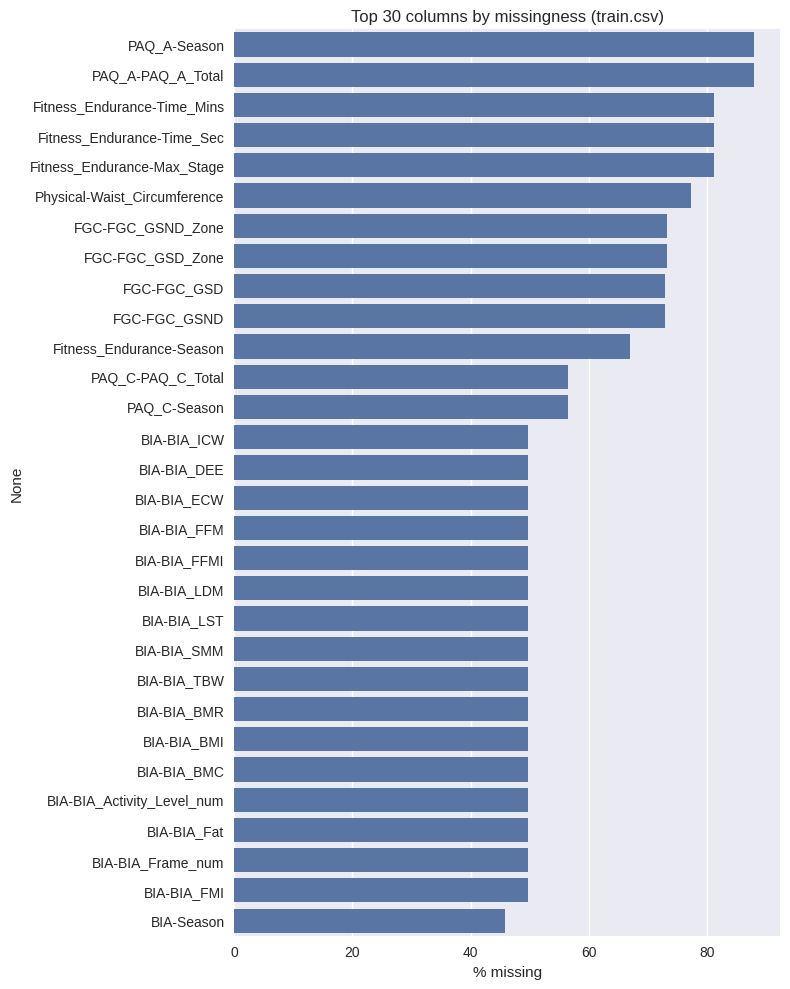

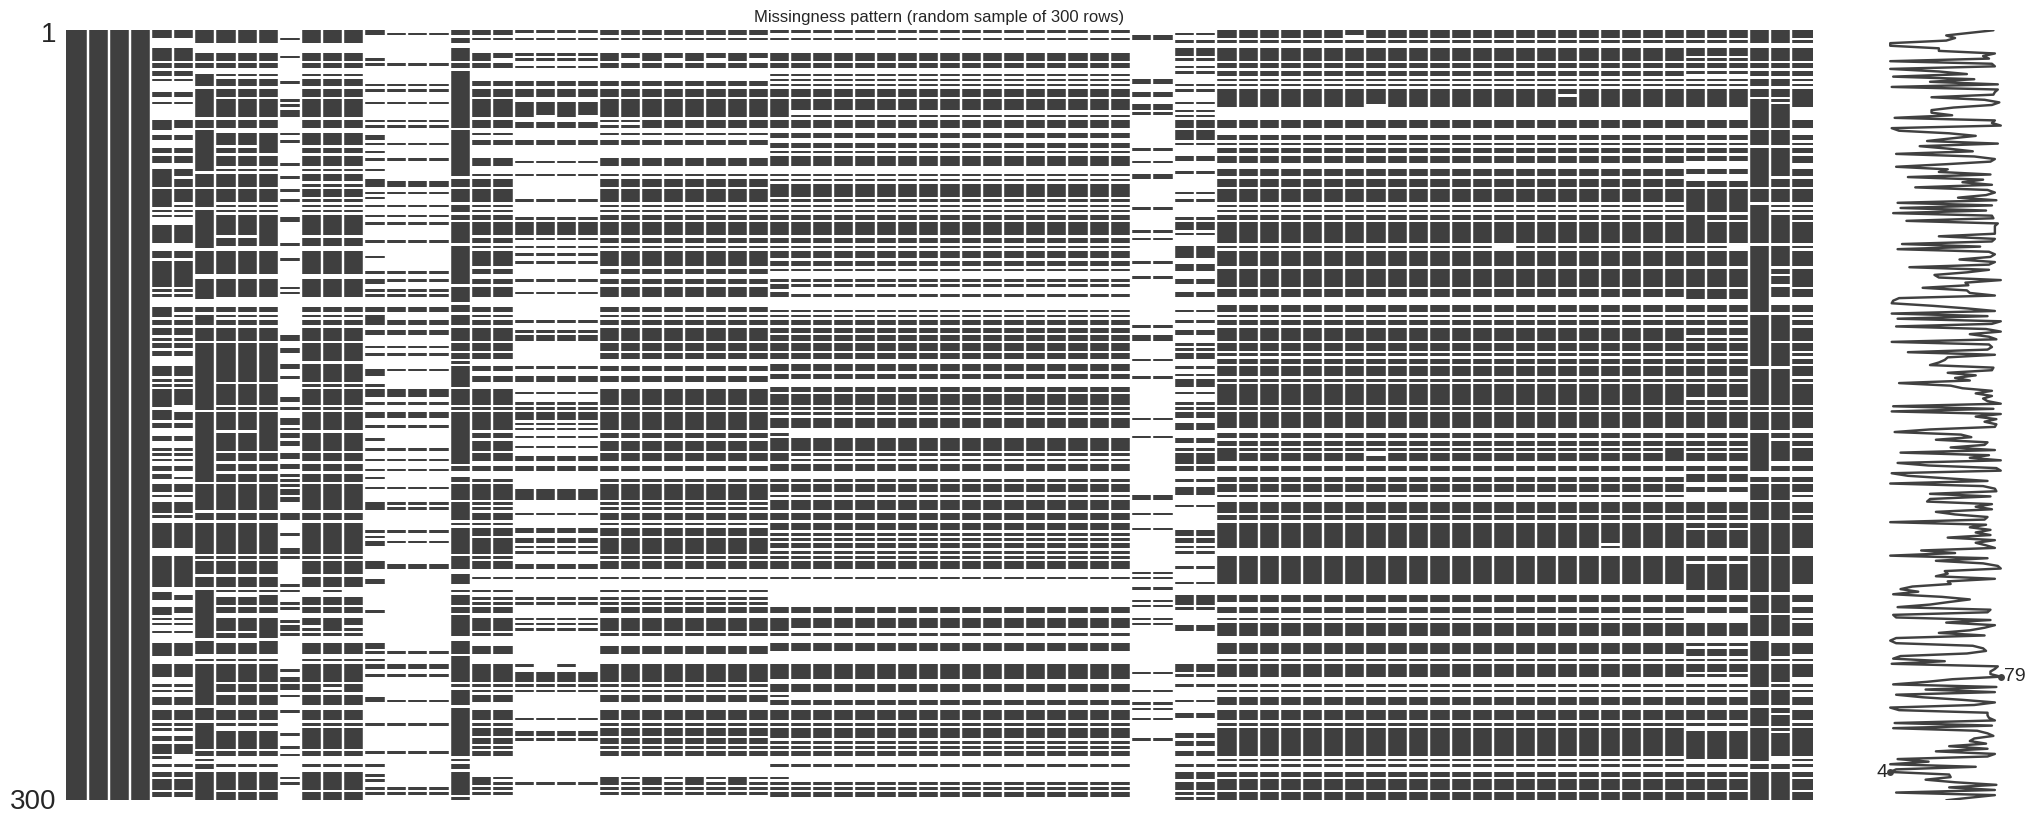

In [17]:
missing = (
    train.isna().mean().sort_values(ascending=False).mul(100).round(1)
    .rename("pct_missing")
    .to_frame()
)
missing["n_missing"] = train.isna().sum().reindex(missing.index)
display(missing.head(30))

plt.figure(figsize=(8, 10))
top_missing = missing.head(30)
sns.barplot(x=top_missing["pct_missing"], y=top_missing.index, color="#4C72B0")
plt.xlabel("% missing")
plt.title("Top 30 columns by missingness (train.csv)")
plt.tight_layout()
plt.show()

try:
    import missingno as msno
    msno.matrix(train.sample(min(300, len(train)), random_state=42))
    plt.title("Missingness pattern (random sample of 300 rows)")
    plt.show()
except ImportError:
    print("missingno not available - skipping matrix plot")


**Observation to carry forward:** questionnaire-instrument missingness (PAQ, FGC, BIA) is largely structural (age-gated instruments, or a participant simply not completing a station), while the accelerometer series is present for only a subset of participants (`series_train.parquet` has one folder per child who wore the device; not every `id` in `train.csv` has a matching recording). We handle this explicitly in Section 3-4: children without actigraphy retain missing wearable features and are imputed at the model-input stage, with imputation applied only to clustering *inputs*, never to the outcome variables used later in Section 10.

## 3. Actigraphy (Accelerometer) Feature Extraction

`series_train.parquet` stores one sub-folder per child (`id=<participant_id>/part-0.parquet`) with 5-second epoch-level accelerometer data: `X`, `Y`, `Z`, `enmo` (Euclidean Norm Minus One, a standard activity-intensity metric), `anglez`, `light`, `battery_voltage`, `non-wear_flag`, `time_of_day` (nanoseconds since midnight), `weekday` (1=Monday...7=Sunday) and `relative_date_PCIAT` (day index relative to the PCIAT assessment).

We reduce each child's raw time series to a small number of **lifestyle-relevant summary features**: how much they sleep, how variable that sleep is, how physically active they are, how variable that activity is, and how different their weekday vs weekend activity looks. This mirrors the "reduce dimensionality" step suggested for the wearable data before it ever reaches UMAP.

**Method transparency (documented simplifications):**
- Epochs are 5 seconds long (`epoch_seconds = 5`).
- Non-wear epochs (`non-wear_flag == 1`) are excluded from all calculations.
- A day is only used if it has at least 16 hours of valid wear time (`min_valid_hours_per_day = 16`), to avoid days dominated by device removal biasing sleep/activity estimates.
- "Night-time" is defined as clock hours 22:00-08:00, derived from `time_of_day`. This is a fixed-window heuristic, **not** a validated polysomnography-grade sleep-staging algorithm.
- An epoch is flagged "low activity" if `enmo < 0.02` (g), a threshold consistent with common wrist-worn accelerometer sleep-detection conventions in the actigraphy literature. Sleep duration for a night is the count of low-activity epochs within the night window, converted to hours.
- "Weekday" = days 1-5, "weekend" = days 6-7 (`weekday` column).

This is intentionally a pragmatic, well-documented simplification appropriate for population-level segmentation - not a clinical sleep score.

In [18]:
EPOCH_SECONDS = 5
LOW_ACTIVITY_ENMO_THRESHOLD = 0.02
MIN_VALID_HOURS_PER_DAY = 16
NIGHT_START_HOUR = 22
NIGHT_END_HOUR = 8


def _hour_of_day(time_of_day_ns):
    """Convert the 'time_of_day' nanoseconds-since-midnight column to a
    fractional clock hour in [0, 24)."""
    return (time_of_day_ns / 1e9) / 3600.0


def extract_actigraphy_features(participant_dir):
    """Summarise one child's accelerometer recording into lifestyle features.

    Returns a dict of features, or None if the recording has no usable
    (sufficiently-worn) days.
    """
    parquet_files = glob.glob(os.path.join(str(participant_dir), "*.parquet"))
    if not parquet_files:
        return None

    df = pq.read_table(parquet_files[0]).to_pandas()
    if "non-wear_flag" in df.columns:
        df = df[df["non-wear_flag"] == 0]
    if df.empty:
        return None

    df["hour"] = _hour_of_day(df["time_of_day"].to_numpy())
    df["is_night"] = (df["hour"] >= NIGHT_START_HOUR) | (df["hour"] < NIGHT_END_HOUR)
    df["is_weekend"] = df["weekday"].isin([6, 7])

    # keep only days with sufficient valid wear time
    epochs_per_day = df.groupby("relative_date_PCIAT").size()
    valid_hours_per_day = epochs_per_day * EPOCH_SECONDS / 3600.0
    valid_days = valid_hours_per_day[valid_hours_per_day >= MIN_VALID_HOURS_PER_DAY].index
    df = df[df["relative_date_PCIAT"].isin(valid_days)]
    if df.empty:
        return None

    # --- sleep duration per night ---
    night_df = df[df["is_night"]]
    sleep_epochs = night_df[night_df["enmo"] < LOW_ACTIVITY_ENMO_THRESHOLD]
    sleep_hours_per_day = (
        sleep_epochs.groupby("relative_date_PCIAT").size() * EPOCH_SECONDS / 3600.0
    )
    sleep_duration_mean = sleep_hours_per_day.mean() if len(sleep_hours_per_day) else np.nan
    sleep_duration_std = sleep_hours_per_day.std() if len(sleep_hours_per_day) > 1 else np.nan

    # --- daytime activity intensity ---
    day_df = df[~df["is_night"]]
    daily_mean_enmo = day_df.groupby("relative_date_PCIAT")["enmo"].mean()
    activity_intensity_mean = daily_mean_enmo.mean() if len(daily_mean_enmo) else np.nan
    activity_intensity_std = daily_mean_enmo.std() if len(daily_mean_enmo) > 1 else np.nan

    # --- weekday vs weekend consistency ---
    weekday_mean = day_df.loc[~day_df["is_weekend"], "enmo"].mean()
    weekend_mean = day_df.loc[day_df["is_weekend"], "enmo"].mean()
    if pd.notna(weekday_mean) and weekday_mean > 0 and pd.notna(weekend_mean):
        weekday_weekend_ratio = weekend_mean / weekday_mean
    else:
        weekday_weekend_ratio = np.nan

    n_valid_days = len(valid_days)

    return {
        "sleep_duration_mean": sleep_duration_mean,
        "sleep_duration_std": sleep_duration_std,
        "activity_intensity_mean": activity_intensity_mean,
        "activity_intensity_std": activity_intensity_std,
        "weekday_weekend_activity_ratio": weekday_weekend_ratio,
        "n_valid_actigraphy_days": n_valid_days,
    }


## 4. Feature Engineering & Merge

We now merge the actigraphy summary onto the tabular data and assemble the final **lifestyle feature set** used for clustering. Following the brief, demographics (age, sex) and outcome measures (PIU / mental health scores) are deliberately **excluded from the clustering inputs** - they are held back for Section 10 (characterisation) so that the segmentation reflects lifestyle only, not the outcomes we later relate it to.

**Clustering input features:**

| Feature | Source | Represents |
|---|---|---|
| `sleep_duration_mean`, `sleep_duration_std` | Actigraphy | Sleep amount & regularity |
| `activity_intensity_mean`, `activity_intensity_std` | Actigraphy | Physical activity level & consistency |
| `weekday_weekend_activity_ratio` | Actigraphy | Routine consistency across the week |
| `BMI` | Physical exam | Body composition |
| `BIA-BIA_Fat`, `BIA-BIA_FFMI`, `BIA-BIA_SMM` | Bioelectrical impedance analysis | Body composition (fat mass, fat-free mass index, skeletal muscle mass) |
| `PAQ_Total` | Physical Activity Questionnaire (self/parent-report) | Self-reported activity level, complementing the objective wearable measure |

**Held back for characterisation only (Section 10):** `Basic_Demos-Age`, `Basic_Demos-Sex`, `PCIAT-PCIAT_Total`, `sii`, `CGAS-CGAS_Score`, `SDS-SDS_Total_T`, `PreInt_EduHx-computerinternet_hoursday`.

In [19]:
if CACHE_PATH.exists():
    actigraphy_summary = pd.read_csv(CACHE_PATH)
    print(f"Loaded cached actigraphy summary: {actigraphy_summary.shape}")
else:
    participant_dirs = sorted(glob.glob(str(SERIES_DIR / "id=*")))
    print(f"Found {len(participant_dirs)} participants with actigraphy recordings")

    try:
        from tqdm.notebook import tqdm
    except ImportError:
        tqdm = lambda x, **kw: x

    records = []
    for pdir in tqdm(participant_dirs, desc="Extracting actigraphy features"):
        participant_id = os.path.basename(pdir).replace("id=", "")
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            feats = extract_actigraphy_features(pdir)
        if feats is not None:
            feats["id"] = participant_id
            records.append(feats)

    actigraphy_summary = pd.DataFrame.from_records(records)
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    actigraphy_summary.to_csv(CACHE_PATH, index=False)
    print(f"Extracted and cached actigraphy summary: {actigraphy_summary.shape}")

display(actigraphy_summary.head())
print("\nCoverage: {}/{} train participants have usable actigraphy features".format(
    train["id"].isin(actigraphy_summary["id"]).sum(), len(train)
))


Found 996 participants with actigraphy recordings


Extracting actigraphy features:   0%|          | 0/996 [00:00<?, ?it/s]

Extracted and cached actigraphy summary: (733, 7)


,sleep_duration_mean,sleep_duration_std,activity_intensity_mean,activity_intensity_std,weekday_weekend_activity_ratio,n_valid_actigraphy_days,id
0,9.162500,0.915095,0.022560,0.005956,1.061219,6,001f3379
1,8.531327,1.696286,0.060600,0.019194,0.713815,18,00f332d1
2,8.654514,0.452433,0.048973,0.008057,0.981366,20,01085eb3
3,9.294722,0.263676,0.095325,0.032603,0.735861,5,012cadd8
4,8.859722,NaN,0.080243,NaN,NaN,1,012e3869



Coverage: 733/3960 train participants have usable actigraphy features


In [20]:
df = train.merge(actigraphy_summary, on="id", how="left")

# harmonise PAQ_A / PAQ_C (age-gated instruments) into a single lifestyle feature
df["PAQ_Total"] = df["PAQ_A-PAQ_A_Total"].combine_first(df["PAQ_C-PAQ_C_Total"])

# prefer the direct physical-exam BMI, falling back to BIA-derived BMI
df["BMI"] = df["Physical-BMI"].combine_first(df["BIA-BIA_BMI"])

CLUSTER_FEATURES = [
    "sleep_duration_mean",
    "sleep_duration_std",
    "activity_intensity_mean",
    "activity_intensity_std",
    "weekday_weekend_activity_ratio",
    "BMI",
    "BIA-BIA_Fat",
    "BIA-BIA_FFMI",
    "BIA-BIA_SMM",
    "PAQ_Total",
]

CHARACTERISATION_VARS = [
    "Basic_Demos-Age",
    "Basic_Demos-Sex",
    "PCIAT-PCIAT_Total",
    "sii",
    "CGAS-CGAS_Score",
    "SDS-SDS_Total_T",
    "PreInt_EduHx-computerinternet_hoursday",
]

print("Missingness of clustering input features:")
display(df[CLUSTER_FEATURES].isna().mean().mul(100).round(1).rename("pct_missing").to_frame())


Missingness of clustering input features:


,pct_missing
sleep_duration_mean,81.5
sleep_duration_std,83.5
activity_intensity_mean,81.5
activity_intensity_std,83.5
weekday_weekend_activity_ratio,85.7
BMI,23.2
BIA-BIA_Fat,49.7
BIA-BIA_FFMI,49.7
BIA-BIA_SMM,49.7
PAQ_Total,44.6


We require at least the actigraphy-derived features to be present (a child must have worn the device to contribute a lifestyle profile), then median-impute any remaining sporadic gaps in the body-composition / questionnaire columns. Median imputation is chosen over mean because several body-composition variables are right-skewed; it is applied only to the small residual missingness left after dropping actigraphy-less rows, and is documented here as a modelling choice rather than silently applied.

In [21]:
has_actigraphy = df["sleep_duration_mean"].notna() & df["activity_intensity_mean"].notna()
print(f"Rows with usable actigraphy: {has_actigraphy.sum()} / {len(df)}")

model_df = df.loc[has_actigraphy, ["id"] + CLUSTER_FEATURES + CHARACTERISATION_VARS].reset_index(drop=True)

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(model_df[CLUSTER_FEATURES])
X_imputed = pd.DataFrame(X_imputed, columns=CLUSTER_FEATURES, index=model_df.index)

print(f"\nFinal modelling sample: {model_df.shape[0]} children, {len(CLUSTER_FEATURES)} lifestyle features")
display(X_imputed.describe().T)


Rows with usable actigraphy: 733 / 3960

Final modelling sample: 733 children, 10 lifestyle features


,count,mean,std,min,25%,50%,75%,max
sleep_duration_mean,733.0,6.469617,2.791149,0.776389,4.095833,7.784167,8.503549,9.718056
sleep_duration_std,733.0,1.112968,0.719606,0.005893,0.606454,0.915095,1.557775,4.382098
activity_intensity_mean,733.0,0.060852,0.026750,0.000013,0.042593,0.058083,0.075546,0.188452
activity_intensity_std,733.0,0.017707,0.010892,0.000549,0.011264,0.015983,0.021115,0.093799
weekday_weekend_activity_ratio,733.0,1.047089,2.161584,0.084938,0.839741,0.939318,1.045585,58.903034
BMI,733.0,19.217302,5.034164,0.000000,15.805295,17.848066,21.469696,45.306026
BIA-BIA_Fat,733.0,19.412982,23.554888,-217.522000,10.458100,15.769300,23.793000,129.226000
BIA-BIA_FFMI,733.0,14.850990,4.159569,12.238500,13.694900,14.127500,14.825600,82.490200
BIA-BIA_SMM,733.0,31.608791,17.737221,12.590300,24.194300,28.213050,32.925100,215.413000
PAQ_Total,733.0,2.460329,0.647988,0.660000,2.140000,2.430000,2.760000,4.560000


## 5. Exploratory Data Analysis

Distributions and pairwise correlations of the engineered lifestyle features, before standardisation.

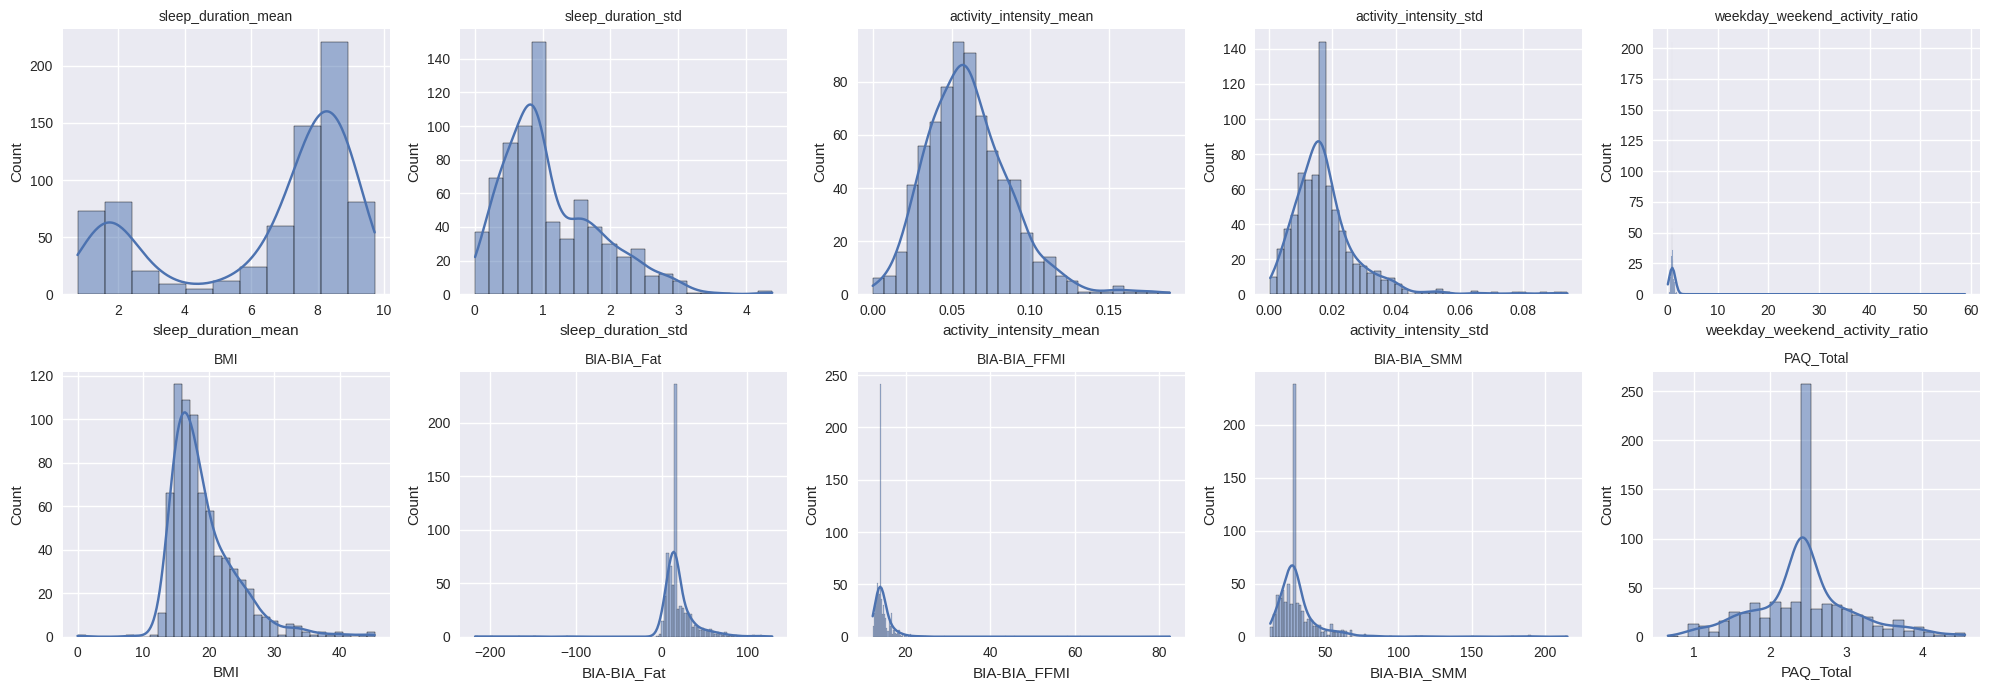

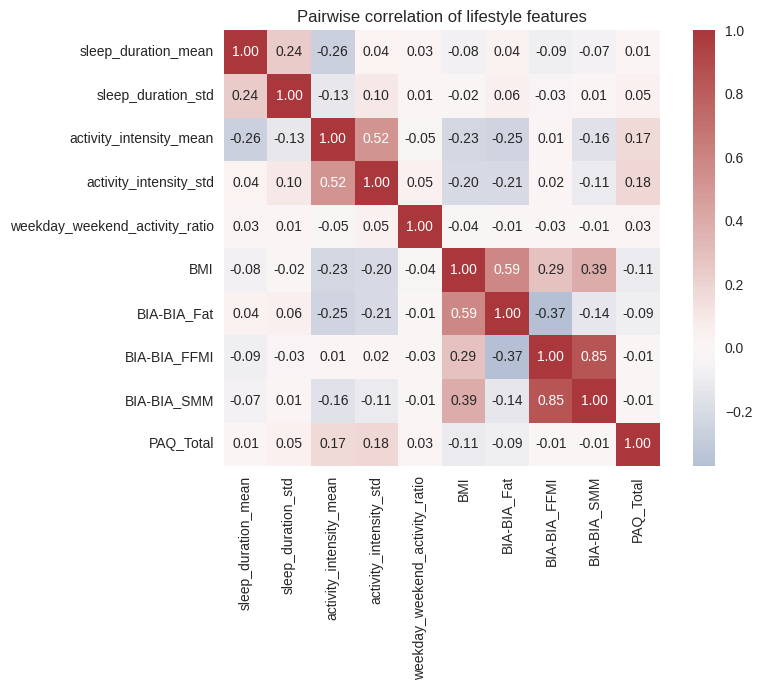

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.flat, CLUSTER_FEATURES):
    sns.histplot(X_imputed[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))
corr = X_imputed.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Pairwise correlation of lifestyle features")
plt.tight_layout()
plt.show()

## 6. Dimensionality Reduction (UMAP)

Features are standardised first (z-scored), since they are on very different scales (hours, g, kg/m^2, questionnaire totals). We then explore how UMAP's `n_neighbors` (local vs global structure) and `min_dist` (how tightly points are allowed to pack) affect the shape of the embedding before committing to final parameters, as required by the brief.

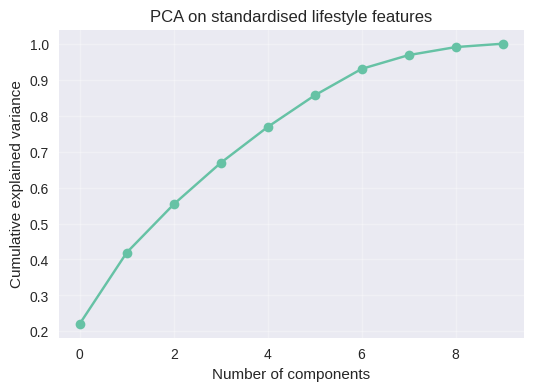

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
X_scaled = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES, index=X_imputed.index)

# quick PCA sanity check - how much variance do the raw features already carry
pca = PCA(random_state=42).fit(X_scaled)
plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA on standardised lifestyle features")
plt.grid(alpha=0.3)
plt.show()


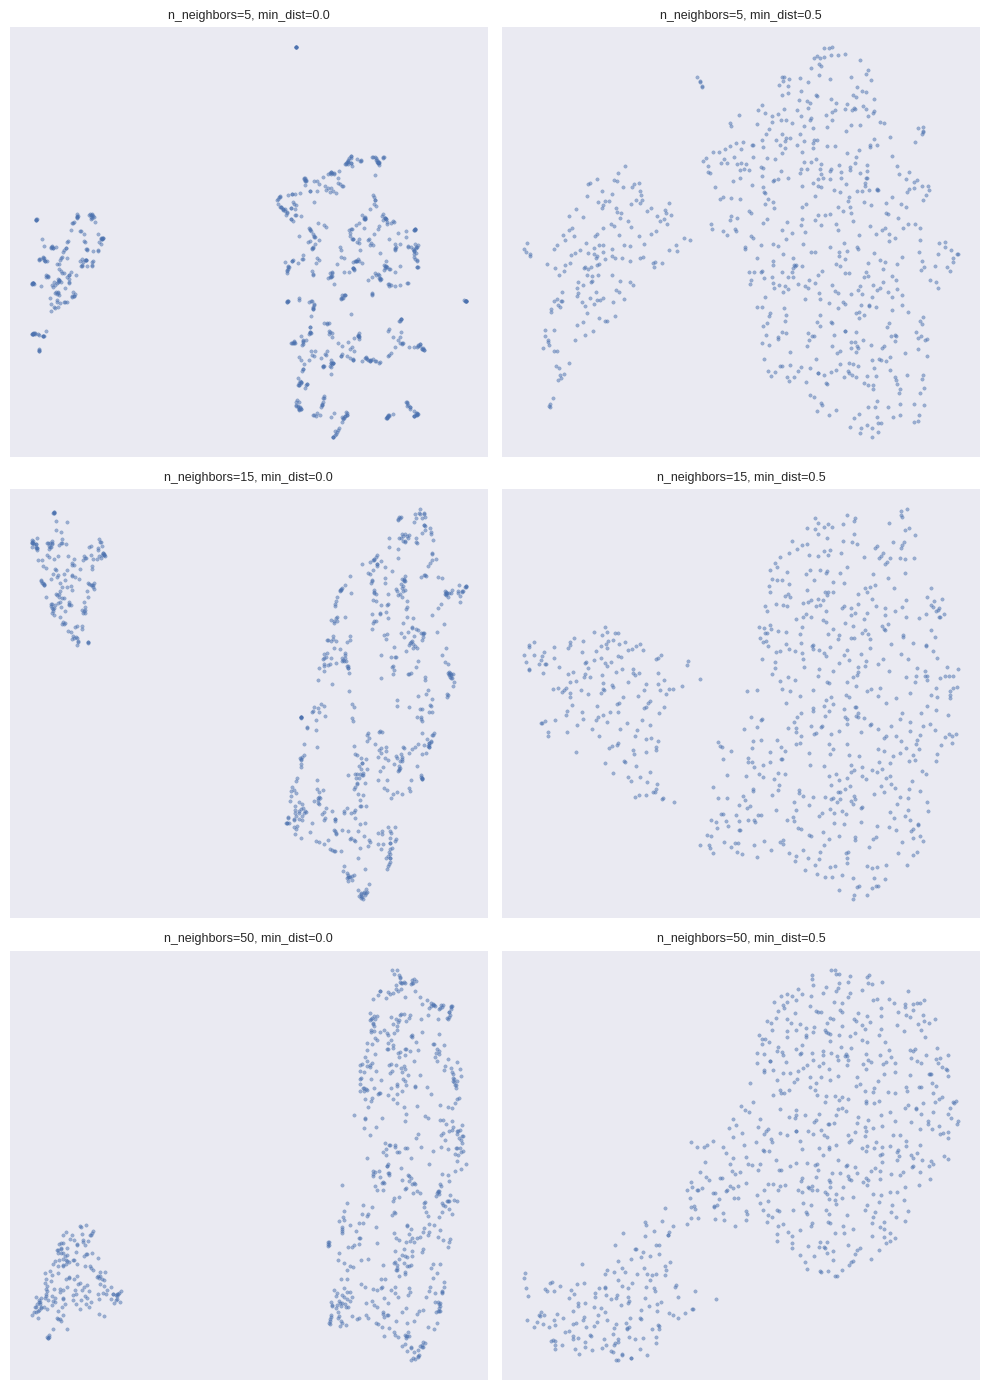

In [24]:
neighbor_grid = [5, 15, 50]
min_dist_grid = [0.0, 0.5]

fig, axes = plt.subplots(len(neighbor_grid), len(min_dist_grid), figsize=(10, 14))
for i, n_neighbors in enumerate(neighbor_grid):
    for j, min_dist in enumerate(min_dist_grid):
        reducer = umap.UMAP(
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            n_components=2,
            random_state=42,
        )
        emb = reducer.fit_transform(X_scaled)
        ax = axes[i, j]
        ax.scatter(emb[:, 0], emb[:, 1], s=6, alpha=0.5, color="#4C72B0")
        ax.set_title(f"n_neighbors={n_neighbors}, min_dist={min_dist}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


**Parameter choice rationale:** a moderate `n_neighbors` (15) balances local detail against the global structure needed for population-level archetypes (very small `n_neighbors` fragments the embedding into noisy local clusters; very large `n_neighbors` over-smooths genuine subgroup structure). A small but non-zero `min_dist` (0.1) keeps groups visually separable without artificially collapsing genuinely continuous variation into artefactual tight blobs. We fit both a 2D embedding (for visualisation) and a higher-dimensional embedding (for clustering itself, which benefits from retaining more structure than 2D allows).

In [25]:
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1

reducer_2d = umap.UMAP(
    n_neighbors=UMAP_N_NEIGHBORS, min_dist=UMAP_MIN_DIST, n_components=2, random_state=42
)
embedding_2d = reducer_2d.fit_transform(X_scaled)

reducer_5d = umap.UMAP(
    n_neighbors=UMAP_N_NEIGHBORS, min_dist=UMAP_MIN_DIST, n_components=5, random_state=42
)
embedding_5d = reducer_5d.fit_transform(X_scaled)

print("2D embedding shape:", embedding_2d.shape)
print("5D embedding shape (used for clustering):", embedding_5d.shape)


2D embedding shape: (733, 2)
5D embedding shape (used for clustering): (733, 5)


## 7. Clustering Comparison

We compare three families of clustering algorithm on the 5D UMAP embedding, each with a different bias: K-means (spherical, evenly-sized clusters), Agglomerative/hierarchical (nested, variable-shape clusters), and DBSCAN (density-based, can flag noise/outliers rather than forcing every child into a cluster). Testing more than one method guards against reporting an artefact of a single algorithm's assumptions.

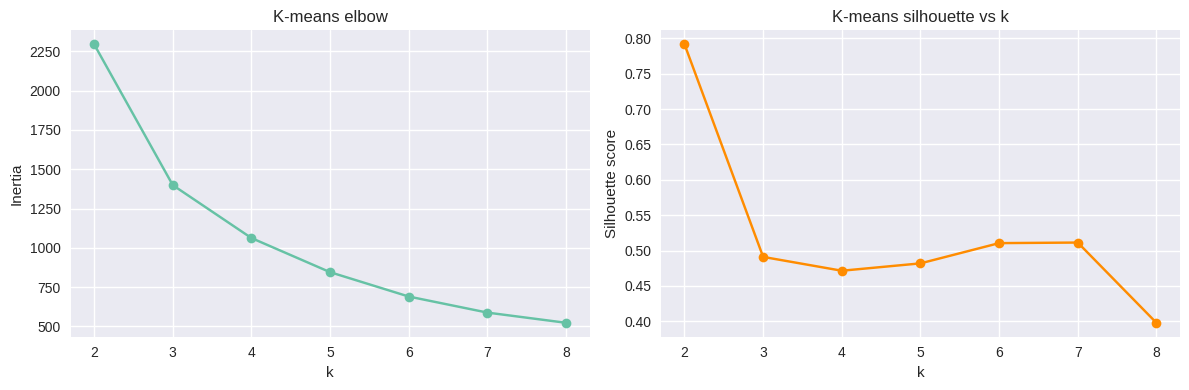

Silhouette-selected k for K-means: 2


In [26]:
# --- K-means: elbow + silhouette across k ---
k_range = range(2, 9)
inertias, sil_scores_km = [], []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(embedding_5d)
    inertias.append(km.inertia_)
    sil_scores_km.append(silhouette_score(embedding_5d, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia"); axes[0].set_title("K-means elbow")
axes[1].plot(list(k_range), sil_scores_km, marker="o", color="darkorange")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score"); axes[1].set_title("K-means silhouette vs k")
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores_km))]
print(f"Silhouette-selected k for K-means: {best_k}")


In [28]:
kmeans_final = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(embedding_5d)
labels_kmeans = kmeans_final.labels_

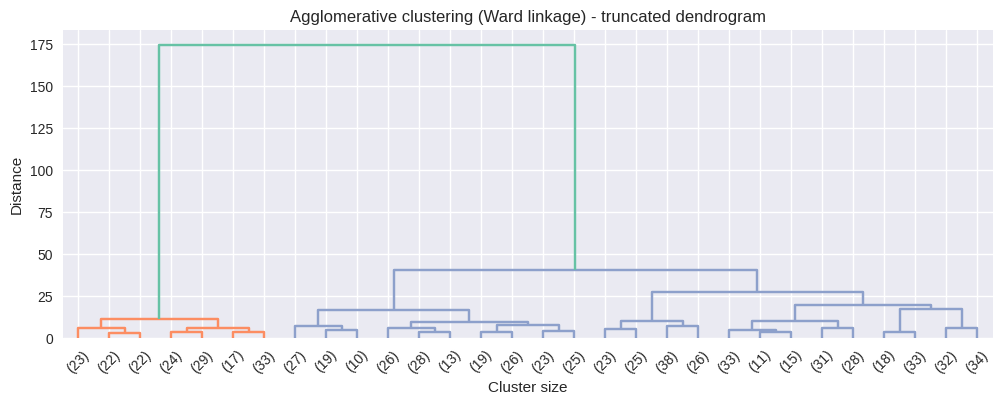

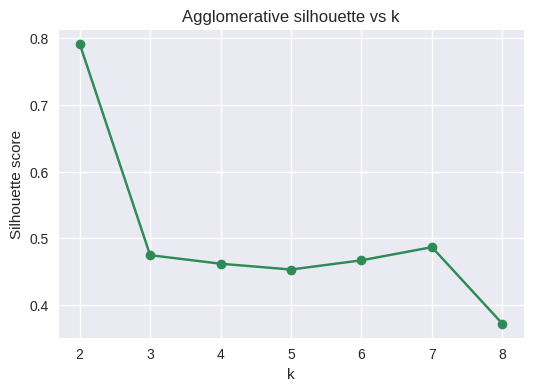

Silhouette-selected k for Agglomerative: 2


In [29]:
# --- Agglomerative (Ward linkage) ---
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(embedding_5d, method="ward")
plt.figure(figsize=(12, 4))
dendrogram(Z, truncate_mode="lastp", p=30, show_leaf_counts=True)
plt.title("Agglomerative clustering (Ward linkage) - truncated dendrogram")
plt.xlabel("Cluster size"); plt.ylabel("Distance")
plt.show()

sil_scores_agg = []
for k in k_range:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward").fit(embedding_5d)
    sil_scores_agg.append(silhouette_score(embedding_5d, agg.labels_))

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), sil_scores_agg, marker="o", color="seagreen")
plt.xlabel("k"); plt.ylabel("Silhouette score"); plt.title("Agglomerative silhouette vs k")
plt.show()

best_k_agg = list(k_range)[int(np.argmax(sil_scores_agg))]
print(f"Silhouette-selected k for Agglomerative: {best_k_agg}")
agg_final = AgglomerativeClustering(n_clusters=best_k_agg, linkage="ward").fit(embedding_5d)
labels_agg = agg_final.labels_

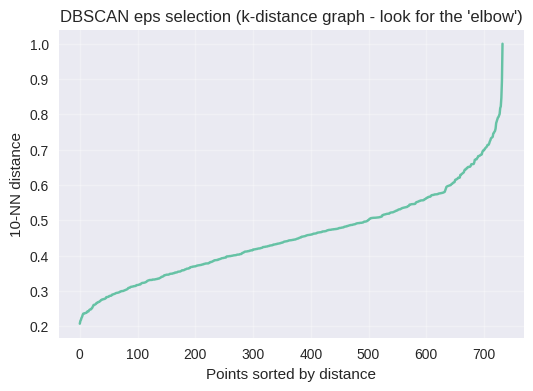

In [30]:
# --- DBSCAN: eps tuning via k-distance graph ---
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 10
neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(embedding_5d)
distances, _ = neighbors.kneighbors(embedding_5d)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance"); plt.ylabel(f"{MIN_SAMPLES}-NN distance")
plt.title("DBSCAN eps selection (k-distance graph - look for the 'elbow')")
plt.grid(alpha=0.3)
plt.show()


In [31]:
# Elbow read from the plot above - adjust EPS if the elbow sits elsewhere for your run
EPS = float(np.percentile(k_distances, 90))
print(f"Selected eps (90th percentile of k-distance, as an elbow proxy): {EPS:.3f}")

dbscan_final = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit(embedding_5d)
labels_dbscan = dbscan_final.labels_
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = int((labels_dbscan == -1).sum())
print(f"DBSCAN found {n_clusters_dbscan} clusters and flagged {n_noise} points as noise ({n_noise/len(labels_dbscan):.1%})")


Selected eps (90th percentile of k-distance, as an elbow proxy): 0.627
DBSCAN found 3 clusters and flagged 1 points as noise (0.1%)


## 8. Cluster Validation

Three complementary internal-validation metrics, each measuring something different:
- **Silhouette score** (-1 to 1, higher better): how well-separated and internally cohesive clusters are, on average, per point.
- **Davies-Bouldin index** (>=0, lower better): average similarity between each cluster and its most-similar other cluster - penalises clusters that are close together relative to their own spread.
- **Calinski-Harabasz index** (higher better): ratio of between-cluster to within-cluster dispersion - sensitive to the number of clusters, so it's read alongside the other two rather than alone.

We compare all three algorithms' chosen solutions on the same footing, and exclude DBSCAN's noise points (-1) from its own metric computation since those points are explicitly "no cluster", not a nominal cluster.

In [32]:
def validation_row(name, X, labels):
    mask = labels != -1  # exclude DBSCAN noise points from validation of the clustered points
    n_clusters = len(set(labels[mask]))
    if n_clusters < 2:
        return {"method": name, "n_clusters": n_clusters, "silhouette": np.nan,
                "davies_bouldin": np.nan, "calinski_harabasz": np.nan}
    return {
        "method": name,
        "n_clusters": n_clusters,
        "silhouette": silhouette_score(X[mask], labels[mask]),
        "davies_bouldin": davies_bouldin_score(X[mask], labels[mask]),
        "calinski_harabasz": calinski_harabasz_score(X[mask], labels[mask]),
    }

validation_table = pd.DataFrame([
    validation_row("K-means", embedding_5d, labels_kmeans),
    validation_row("Agglomerative", embedding_5d, labels_agg),
    validation_row("DBSCAN", embedding_5d, labels_dbscan),
]).round(3)

display(validation_table)


,method,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,K-means,2,0.792,0.257,4862.640137
1,Agglomerative,2,0.792,0.257,4862.640137
2,DBSCAN,3,0.288,0.671,2561.410889


## 9. Stability Analysis

A clustering solution that looks clean on one run but collapses under mild perturbation is not a reliable finding. We test the K-means solution (our leading candidate, pending Section 8's results) two ways:

1. **Subsampling stability:** repeatedly re-cluster random 80% subsamples and measure agreement (Adjusted Rand Index) with cluster labels on the shared, overlapping points.
2. **Noise sensitivity:** add small Gaussian noise to the standardised input features, re-embed and re-cluster, and measure agreement with the original labelling.

ARI ranges from ~0 (agreement no better than chance) to 1 (perfect agreement).

In [33]:
from sklearn.metrics import adjusted_rand_score

N_TRIALS = 10
SUBSAMPLE_FRAC = 0.8

subsample_aris = []
rng = np.random.RandomState(42)
for trial in range(N_TRIALS):
    idx = rng.choice(len(embedding_5d), size=int(len(embedding_5d) * SUBSAMPLE_FRAC), replace=False)
    idx_sorted = np.sort(idx)
    km_sub = KMeans(n_clusters=best_k, n_init=10, random_state=trial).fit(embedding_5d[idx_sorted])
    ari = adjusted_rand_score(labels_kmeans[idx_sorted], km_sub.labels_)
    subsample_aris.append(ari)

print(f"Subsampling stability (k={best_k}, {N_TRIALS} trials, {SUBSAMPLE_FRAC:.0%} subsamples):")
print(f"  mean ARI = {np.mean(subsample_aris):.3f}  (std = {np.std(subsample_aris):.3f})")


Subsampling stability (k=2, 10 trials, 80% subsamples):
  mean ARI = 1.000  (std = 0.000)


In [34]:
NOISE_SIGMA = 0.1  # in standardised-feature units

noise_aris = []
for trial in range(N_TRIALS):
    rs = np.random.RandomState(100 + trial)
    X_noisy = X_scaled.to_numpy() + rs.normal(0, NOISE_SIGMA, X_scaled.shape)
    reducer_noisy = umap.UMAP(
        n_neighbors=UMAP_N_NEIGHBORS, min_dist=UMAP_MIN_DIST, n_components=5, random_state=trial
    )
    emb_noisy = reducer_noisy.fit_transform(X_noisy)
    km_noisy = KMeans(n_clusters=best_k, n_init=10, random_state=trial).fit(emb_noisy)
    ari = adjusted_rand_score(labels_kmeans, km_noisy.labels_)
    noise_aris.append(ari)

print(f"Noise sensitivity (sigma={NOISE_SIGMA}, {N_TRIALS} trials):")
print(f"  mean ARI = {np.mean(noise_aris):.3f}  (std = {np.std(noise_aris):.3f})")

print(
    "\nInterpretation guide: ARI > 0.6 suggests a reasonably stable solution; "
    "0.3-0.6 suggests moderate stability worth flagging as a limitation; "
    "< 0.3 suggests the solution should be treated as provisional/exploratory only."
)


Noise sensitivity (sigma=0.1, 10 trials):
  mean ARI = 0.993  (std = 0.006)

Interpretation guide: ARI > 0.6 suggests a reasonably stable solution; 0.3-0.6 suggests moderate stability worth flagging as a limitation; < 0.3 suggests the solution should be treated as provisional/exploratory only.


## 10. Archetype Characterisation

We adopt the K-means solution (pending the validation/stability results above being the strongest of the three) as the final archetype assignment, attach it back to the modelling dataframe, and describe each archetype in terms of its lifestyle features, demographics, and - as a **preliminary, subset-derived association only** - its relationship to PIU and mental health screening scores.

In [35]:
FINAL_LABELS = labels_kmeans  # swap to labels_agg / labels_dbscan here if validation favours another method

model_df = model_df.copy()
model_df["archetype"] = FINAL_LABELS
model_df["archetype"] = model_df["archetype"].astype("category")

print("Archetype sizes:")
display(model_df["archetype"].value_counts().sort_index())


Archetype sizes:


archetype
0    563
1    170
Name: count, dtype: int64

In [36]:
# --- lifestyle-feature profile per archetype ---
profile = model_df.groupby("archetype")[CLUSTER_FEATURES].agg(["mean", "std"])
display(profile.round(2))

# --- ANOVA / Kruskal-Wallis: do lifestyle features differ significantly by archetype? ---
print("\nSignificance of lifestyle-feature differences across archetypes:")
for feat in CLUSTER_FEATURES:
    groups = [g[feat].dropna().values for _, g in model_df.groupby("archetype")]
    f_stat, p_anova = f_oneway(*groups)
    h_stat, p_kw = kruskal(*groups)
    print(f"  {feat:32s}  ANOVA p={p_anova:.4f}   Kruskal-Wallis p={p_kw:.4f}")


sleep_duration_mean       sleep_duration_std        \
                         mean   std               mean   std   
archetype                                                      
0                        7.86  1.28               1.29  0.74   
1                        1.85  0.59               0.43  0.30   

          activity_intensity_mean       activity_intensity_std        \
                             mean   std                   mean   std   
archetype                                                              
0                            0.06  0.03                   0.02  0.01   
1                            0.07  0.03                   0.01  0.01   

          weekday_weekend_activity_ratio          BMI       BIA-BIA_Fat  \
                                    mean   std   mean   std        mean   
archetype                                                                 
0                                   1.08  2.61  19.11  4.95       20.72   
1                                   1.04  0.29  19.60  5.35       20.85   

                 BIA-BIA_FFMI       BIA-BIA_SMM        PAQ_Total       
             std         mean   std        mean    std      mean  std  
archetype                                                              
0          29.83        15.31  5.46       33.51  22.62      2.48  0.8  
1          18.08        14.51  1.75       30.81  12.22      2.46  0.7


Significance of lifestyle-feature differences across archetypes:
  sleep_duration_mean               ANOVA p=0.0000   Kruskal-Wallis p=0.0000
  sleep_duration_std                ANOVA p=0.0000   Kruskal-Wallis p=0.0000
  activity_intensity_mean           ANOVA p=0.0000   Kruskal-Wallis p=0.0000
  activity_intensity_std            ANOVA p=0.0006   Kruskal-Wallis p=0.0003
  weekday_weekend_activity_ratio    ANOVA p=0.8846   Kruskal-Wallis p=0.0455
  BMI                               ANOVA p=0.2668   Kruskal-Wallis p=0.4614
  BIA-BIA_Fat                       ANOVA p=0.9616   Kruskal-Wallis p=0.3528
  BIA-BIA_FFMI                      ANOVA p=0.0994   Kruskal-Wallis p=0.1903
  BIA-BIA_SMM                       ANOVA p=0.1930   Kruskal-Wallis p=0.9279
  PAQ_Total                         ANOVA p=0.8288   Kruskal-Wallis p=0.9363


In [37]:
# --- sex distribution across archetypes (chi-square) ---
sex_table = pd.crosstab(model_df["archetype"], model_df["Basic_Demos-Sex"])
chi2, p_chi2, dof, _ = chi2_contingency(sex_table)
print("Sex distribution by archetype:")
display(sex_table)
print(f"Chi-square test: chi2={chi2:.2f}, dof={dof}, p={p_chi2:.4f}")

print("\nAge distribution by archetype:")
display(model_df.groupby("archetype")["Basic_Demos-Age"].describe().round(2))


Sex distribution by archetype:


Basic_Demos-Sex,0,1
archetype,,
0,371,192
1,119,51


Chi-square test: chi2=0.82, dof=1, p=0.3665

Age distribution by archetype:


,count,mean,std,min,25%,50%,75%,max
archetype,,,,,,,,
0,563.0,10.27,3.36,5.0,8.0,10.0,12.0,21.0
1,170.0,9.81,3.06,5.0,8.0,9.0,11.0,20.0


### Relating archetypes to PIU and mental health screening scores

**Caution:** `PCIAT-PCIAT_Total`, `sii`, `CGAS-CGAS_Score` and `SDS-SDS_Total_T` were **not** used to form the archetypes above; they are examined here only to describe how the lifestyle-based segmentation relates to these screening outcomes. This is an **association from train-set labels on a subset of participants with usable actigraphy**, and should be read as hypothesis-generating, not as a validated clinical finding.

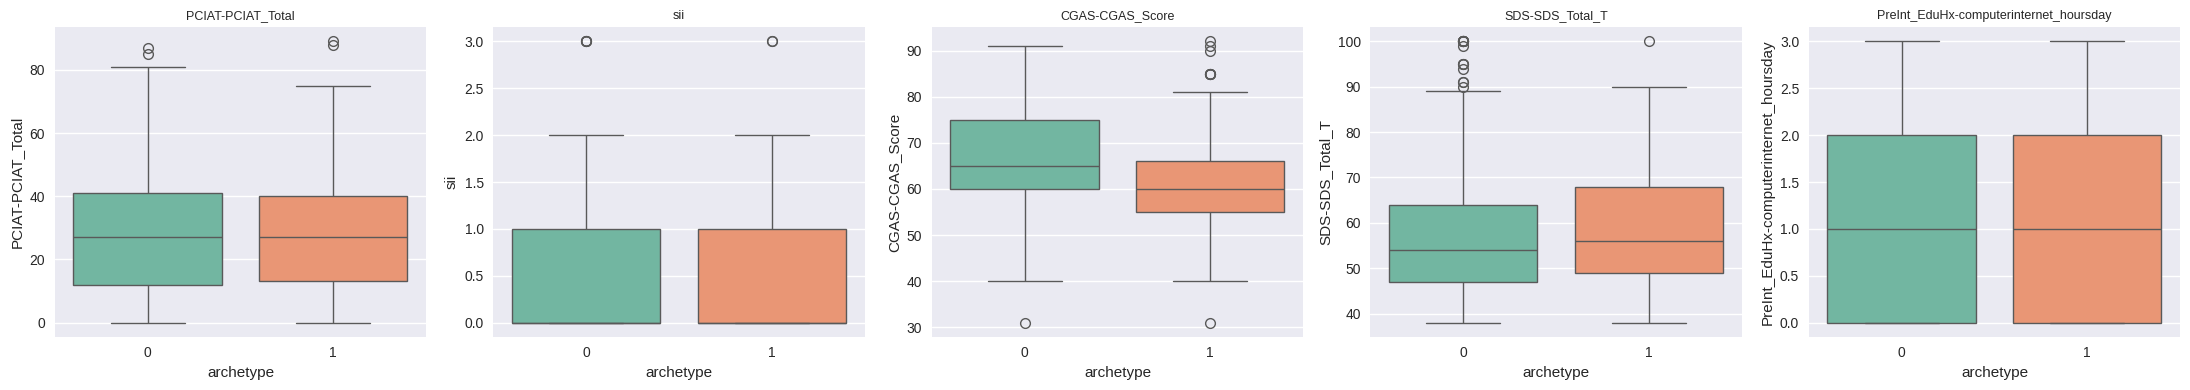

Significance of outcome differences across archetypes (Kruskal-Wallis, robust to non-normal screening scores):
  PCIAT-PCIAT_Total                           Kruskal-Wallis p=0.8181
  sii                                         Kruskal-Wallis p=0.5511
  CGAS-CGAS_Score                             Kruskal-Wallis p=0.0000
  SDS-SDS_Total_T                             Kruskal-Wallis p=0.3256
  PreInt_EduHx-computerinternet_hoursday      Kruskal-Wallis p=0.7718

sii (Severity Impairment Index category) distribution by archetype:


sii,0.0,1.0,2.0,3.0
archetype,,,,
0,0.58,0.27,0.14,0.01
1,0.60,0.29,0.10,0.01


In [38]:
outcome_vars = ["PCIAT-PCIAT_Total", "sii", "CGAS-CGAS_Score", "SDS-SDS_Total_T",
                "PreInt_EduHx-computerinternet_hoursday"]

fig, axes = plt.subplots(1, len(outcome_vars), figsize=(22, 4))
for ax, col in zip(axes, outcome_vars):
    sns.boxplot(data=model_df, x="archetype", y=col, ax=ax, palette="Set2")
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

print("Significance of outcome differences across archetypes (Kruskal-Wallis, robust to non-normal screening scores):")
for col in outcome_vars:
    groups = [g[col].dropna().values for _, g in model_df.groupby("archetype")]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        continue
    h_stat, p_val = kruskal(*groups)
    print(f"  {col:42s}  Kruskal-Wallis p={p_val:.4f}")

print("\nsii (Severity Impairment Index category) distribution by archetype:")
display(pd.crosstab(model_df["archetype"], model_df["sii"], normalize="index").round(2))


## 11. Visual Summary

UMAP scatter coloured by final archetype, plus one radar chart per archetype and a heatmap of standardised feature means - the requested "one clear summary visualisation per archetype".

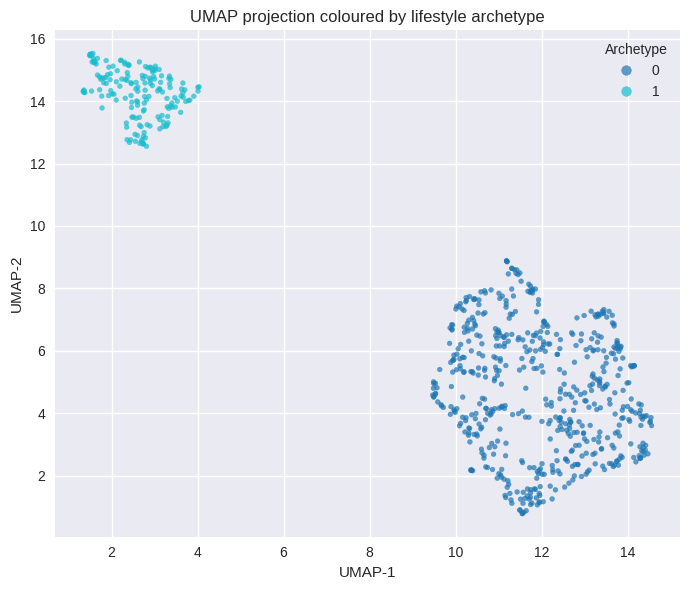

In [39]:
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    embedding_2d[:, 0], embedding_2d[:, 1],
    c=FINAL_LABELS, cmap="tab10", s=12, alpha=0.7
)
plt.legend(*scatter.legend_elements(), title="Archetype", loc="best")
plt.title("UMAP projection coloured by lifestyle archetype")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()


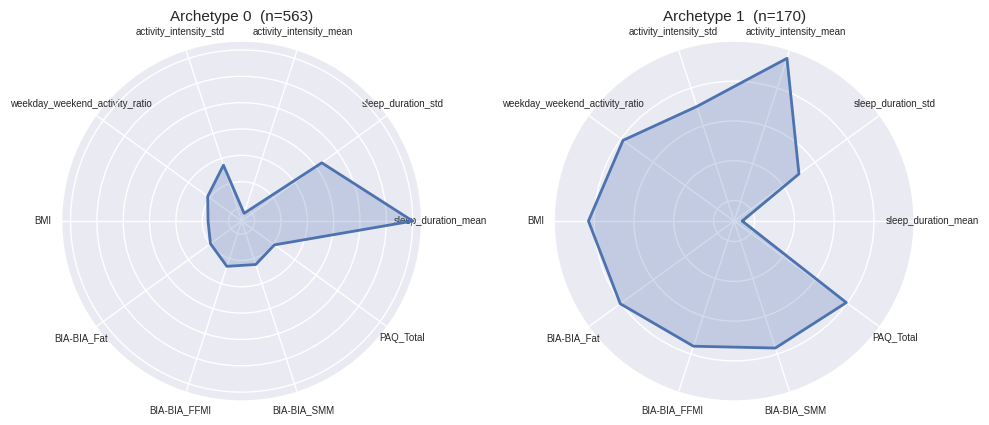

In [40]:
# standardised feature means per archetype, for the radar charts and heatmap
archetype_means_scaled = (
    pd.DataFrame(X_scaled.values, columns=CLUSTER_FEATURES, index=model_df.index)
    .groupby(model_df["archetype"])
    .mean()
)

def radar_chart(ax, values, labels, title):
    n = len(labels)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    values = list(values) + [values[0]]
    angles = angles + [angles[0]]
    ax.plot(angles, values, color="#4C72B0", linewidth=2)
    ax.fill(angles, values, color="#4C72B0", alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_title(title, fontsize=11, pad=15)
    ax.set_yticklabels([])

n_arch = archetype_means_scaled.shape[0]
fig, axes = plt.subplots(1, n_arch, subplot_kw=dict(polar=True), figsize=(5 * n_arch, 5))
if n_arch == 1:
    axes = [axes]
for ax, (arch_id, row) in zip(axes, archetype_means_scaled.iterrows()):
    n_members = (model_df["archetype"] == arch_id).sum()
    radar_chart(ax, row.values, CLUSTER_FEATURES, f"Archetype {arch_id}  (n={n_members})")
plt.tight_layout()
plt.show()


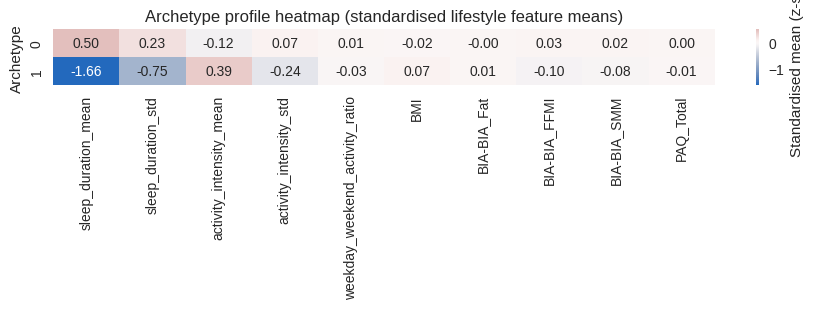

In [41]:
plt.figure(figsize=(9, max(3, 0.6 * n_arch + 2)))
sns.heatmap(
    archetype_means_scaled, annot=True, fmt=".2f", cmap="vlag", center=0,
    cbar_kws={"label": "Standardised mean (z-score)"}
)
plt.title("Archetype profile heatmap (standardised lifestyle feature means)")
plt.ylabel("Archetype")
plt.tight_layout()
plt.show()


## 12. Optional Stretch: Robustness of the Archetype-PIU Association

As a robustness check, we re-cluster with a different `k` and a different UMAP `n_neighbors`, and see whether the direction of the archetype-PIU association (which archetypes have higher/lower `PCIAT-PCIAT_Total`) holds up, rather than being an artefact of one specific parameter choice.

In [42]:
alt_k = max(2, best_k - 1) if best_k > 2 else best_k + 1
alt_reducer = umap.UMAP(n_neighbors=30, min_dist=UMAP_MIN_DIST, n_components=5, random_state=7)
alt_embedding = alt_reducer.fit_transform(X_scaled)
alt_labels = KMeans(n_clusters=alt_k, n_init=10, random_state=7).fit_predict(alt_embedding)

alt_df = model_df.copy()
alt_df["alt_archetype"] = alt_labels

print(f"Alternative run: k={alt_k}, n_neighbors=30 (vs. original k={best_k}, n_neighbors={UMAP_N_NEIGHBORS})")
print("\nPCIAT-PCIAT_Total mean by alternative archetype:")
display(alt_df.groupby("alt_archetype")["PCIAT-PCIAT_Total"].mean().round(1))

groups = [g["PCIAT-PCIAT_Total"].dropna().values for _, g in alt_df.groupby("alt_archetype")]
h_stat, p_val = kruskal(*[g for g in groups if len(g) > 0])
print(f"\nKruskal-Wallis p={p_val:.4f} (alternative parameterisation)")
print(
    "Robustness read: if archetypes with the lowest sleep / highest activity-variability "
    "profile also show the highest PCIAT scores under this alternative parameterisation, "
    "that supports the original finding being a genuine pattern rather than a clustering artefact."
)


Alternative run: k=3, n_neighbors=30 (vs. original k=2, n_neighbors=15)

PCIAT-PCIAT_Total mean by alternative archetype:


alt_archetype
0    23.7
1    27.4
2    33.2
Name: PCIAT-PCIAT_Total, dtype: float64


Kruskal-Wallis p=0.0000 (alternative parameterisation)
Robustness read: if archetypes with the lowest sleep / highest activity-variability profile also show the highest PCIAT scores under this alternative parameterisation, that supports the original finding being a genuine pattern rather than a clustering artefact.
